<a href="https://colab.research.google.com/github/kapilpandey09/ML_project/blob/main/Car_price_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
deepcontractor_car_price_prediction_challenge_path = kagglehub.dataset_download('deepcontractor/car-price-prediction-challenge')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepcontractor/car-price-prediction-challenge/car_price_prediction.csv


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/deepcontractor/car-price-prediction-challenge/car_price_prediction.csv")

In [ ]:
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [ ]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [ ]:
df.shape

(19237, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [ ]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df[df["Price"] != "-"]
df = df[df["Levy"] != "-"]
df = df[df["Mileage"] != "-"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13215 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                13215 non-null  int64  
 1   Price             13215 non-null  int64  
 2   Levy              13215 non-null  object 
 3   Manufacturer      13215 non-null  object 
 4   Model             13215 non-null  object 
 5   Prod. year        13215 non-null  int64  
 6   Category          13215 non-null  object 
 7   Leather interior  13215 non-null  object 
 8   Fuel type         13215 non-null  object 
 9   Engine volume     13215 non-null  object 
 10  Mileage           13215 non-null  object 
 11  Cylinders         13215 non-null  float64
 12  Gear box type     13215 non-null  object 
 13  Drive wheels      13215 non-null  object 
 14  Doors             13215 non-null  object 
 15  Wheel             13215 non-null  object 
 16  Color             13215 non-null  object 
 17

In [ ]:
df["Mileage"] = df["Mileage"].str.replace(" km", "").str.replace(",", "").astype(int)

In [ ]:
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")
df["Levy"].fillna(df["Levy"].median(), inplace=True)

/tmp/ipykernel_55/1186868447.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Levy"].fillna(df["Levy"].median(), inplace=True)


In [ ]:
df["Fuel type"].value_counts()

Fuel type
Petrol            6603
Diesel            3165
Hybrid            2750
LPG                638
Plug-in Hybrid      41
CNG                 18
Name: count, dtype: int64

In [ ]:
# Clean Price column
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df.dropna(subset=["Price"], inplace=True)

# Clean Engine volume (remove 'Turbo')
df["Engine volume"] = df["Engine volume"].str.replace(" Turbo", "").astype(float)

# Remove extreme outliers in Price
df = df[df["Price"] < 100000]

print("Cleaned shape:", df.shape)

Cleaned shape: (13162, 18)


In [ ]:
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,04-May,Left wheel,White,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19231,45772306,5802,1055,MERCEDES-BENZ,E 350,2013,Sedan,Yes,Diesel,3.5,107800,6.0,Automatic,Rear,04-May,Left wheel,Grey,12
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13162 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                13162 non-null  int64  
 1   Price             13162 non-null  int64  
 2   Levy              13162 non-null  int64  
 3   Manufacturer      13162 non-null  object 
 4   Model             13162 non-null  object 
 5   Prod. year        13162 non-null  int64  
 6   Category          13162 non-null  object 
 7   Leather interior  13162 non-null  object 
 8   Fuel type         13162 non-null  object 
 9   Engine volume     13162 non-null  float64
 10  Mileage           13162 non-null  int64  
 11  Cylinders         13162 non-null  float64
 12  Gear box type     13162 non-null  object 
 13  Drive wheels      13162 non-null  object 
 14  Doors             13162 non-null  object 
 15  Wheel             13162 non-null  object 
 16  Color             13162 non-null  object 
 17

In [ ]:
# Check current column names
print("Before:", df.columns.tolist())

# Clean column names
df.columns = (df.columns
                .str.strip()                    # remove leading/trailing spaces
                .str.lower()                    # make lowercase
                .str.replace(" ", "_")          # spaces → underscore
                .str.replace(".", "")           # remove dots
                .str.replace("/", "_")          # slash → underscore
                .str.replace("-", "_")          # dash → underscore
)

# Check after
print("\nAfter:", df.columns.tolist())

Before: ['id', 'price', 'levy', 'manufacturer', 'model', 'prod_year', 'category', 'leather_interior', 'fuel_type', 'engine_volume', 'mileage', 'cylinders', 'gear_box_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags']

After: ['id', 'price', 'levy', 'manufacturer', 'model', 'prod_year', 'category', 'leather_interior', 'fuel_type', 'engine_volume', 'mileage', 'cylinders', 'gear_box_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags']


In [ ]:
df.drop("id", axis=1, inplace=True)
print("✅ ID column dropped")

✅ ID column dropped


/tmp/ipykernel_55/766229805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("id", axis=1, inplace=True)


In [ ]:
# Check what's inside Doors
print(df["doors"].value_counts())

# Fix it
df["doors"] = df["doors"].replace({
    "04-May": 4,
    "02-Mar": 2,
    ">5": 6
})
df["doors"] = pd.to_numeric(df["doors"], errors="coerce")
df["doors"].fillna(df["doors"].mode()[0], inplace=True)
print("✅ Doors column fixed")

doors
04-May    12918
02-Mar      210
>5           34
Name: count, dtype: int64
✅ Doors column fixed


/tmp/ipykernel_55/3657041884.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["doors"] = df["doors"].replace({
/tmp/ipykernel_55/3657041884.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["doors"] = df["doors"].replace({
/tmp/ipykernel_55/3657041884.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [ ]:
# encoding "Fuel_type" Columns
df.replace({'fuel_type':{
    "Petrol"        : 0,
    "Diesel"        : 1,
    "Hybrid"        : 2,
    "CNG"           : 3,
    "Hydrogen"      : 4,
    "Plug-in Hybrid": 5,
    "LPG"           : 6}}, inplace=True)

/tmp/ipykernel_55/1443804012.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'fuel_type':{
/tmp/ipykernel_55/1443804012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace({'fuel_type':{


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13162 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             13162 non-null  int64  
 1   levy              13162 non-null  int64  
 2   manufacturer      13162 non-null  object 
 3   model             13162 non-null  object 
 4   prod_year         13162 non-null  int64  
 5   category          13162 non-null  object 
 6   leather_interior  13162 non-null  object 
 7   fuel_type         13162 non-null  int64  
 8   engine_volume     13162 non-null  float64
 9   mileage           13162 non-null  int64  
 10  cylinders         13162 non-null  float64
 11  gear_box_type     13162 non-null  object 
 12  drive_wheels      13162 non-null  object 
 13  doors             13162 non-null  int64  
 14  wheel             13162 non-null  object 
 15  color             13162 non-null  object 
 16  airbags           13162 non-null  int64  
dty

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13162 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             13162 non-null  int64  
 1   levy              13162 non-null  int64  
 2   manufacturer      13162 non-null  object 
 3   model             13162 non-null  object 
 4   prod_year         13162 non-null  int64  
 5   category          13162 non-null  object 
 6   leather_interior  13162 non-null  object 
 7   fuel_type         13162 non-null  int64  
 8   engine_volume     13162 non-null  float64
 9   mileage           13162 non-null  int64  
 10  cylinders         13162 non-null  float64
 11  gear_box_type     13162 non-null  object 
 12  drive_wheels      13162 non-null  object 
 13  doors             13162 non-null  int64  
 14  wheel             13162 non-null  object 
 15  color             13162 non-null  object 
 16  airbags           13162 non-null  int64  
dty

In [ ]:
# These still need encoding
object_cols = df.select_dtypes(include="object").columns
print("Still object:", object_cols.tolist())

# Encode them
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in object_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ All encoded!")

Still object: ['manufacturer', 'model', 'category', 'leather_interior', 'gear_box_type', 'drive_wheels', 'wheel', 'color']
✅ All encoded!


/tmp/ipykernel_55/2568997064.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
/tmp/ipykernel_55/2568997064.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
/tmp/ipykernel_55/2568997064.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13162 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             13162 non-null  int64  
 1   levy              13162 non-null  int64  
 2   manufacturer      13162 non-null  int64  
 3   model             13162 non-null  int64  
 4   prod_year         13162 non-null  int64  
 5   category          13162 non-null  int64  
 6   leather_interior  13162 non-null  int64  
 7   fuel_type         13162 non-null  int64  
 8   engine_volume     13162 non-null  float64
 9   mileage           13162 non-null  int64  
 10  cylinders         13162 non-null  float64
 11  gear_box_type     13162 non-null  int64  
 12  drive_wheels      13162 non-null  int64  
 13  doors             13162 non-null  int64  
 14  wheel             13162 non-null  int64  
 15  color             13162 non-null  int64  
 16  airbags           13162 non-null  int64  
dty

price               1.000000
prod_year           0.310174
gear_box_type       0.128842
model               0.093257
levy                0.031593
doors               0.025208
drive_wheels        0.022889
leather_interior    0.013228
color               0.006365
engine_volume      -0.000671
mileage            -0.003521
cylinders          -0.032879
wheel              -0.060771
manufacturer       -0.070224
fuel_type          -0.111167
category           -0.123066
airbags            -0.203565
Name: price, dtype: float64


/tmp/ipykernel_55/126998773.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


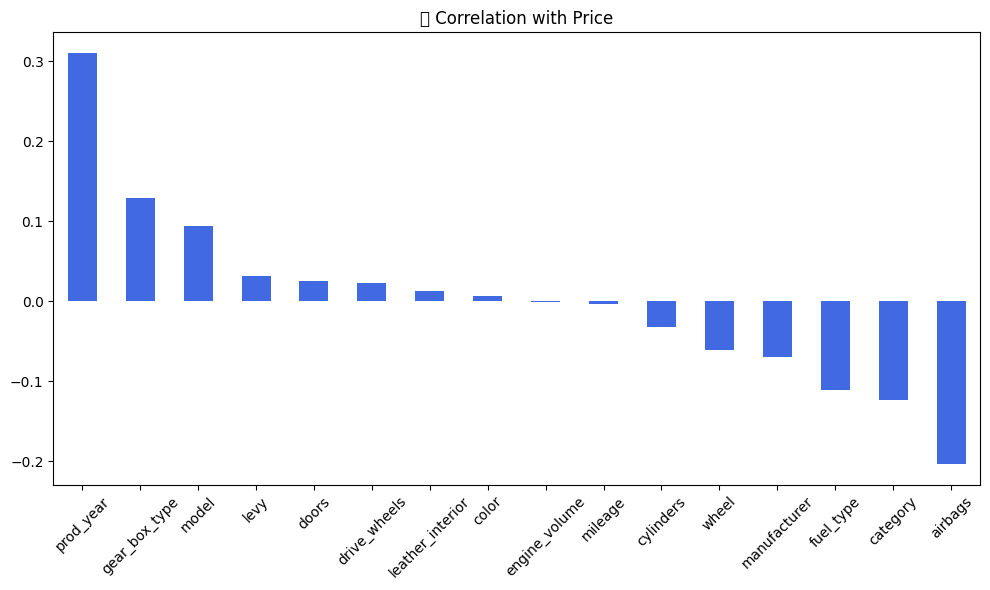

In [ ]:
correlation = df.corr()["price"].sort_values(ascending=False)
print(correlation)

# Plot
plt.figure(figsize=(10,6))
correlation.drop("price").plot(kind="bar", color="royalblue")
plt.title("📊 Correlation with Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/2825193624.py:5: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


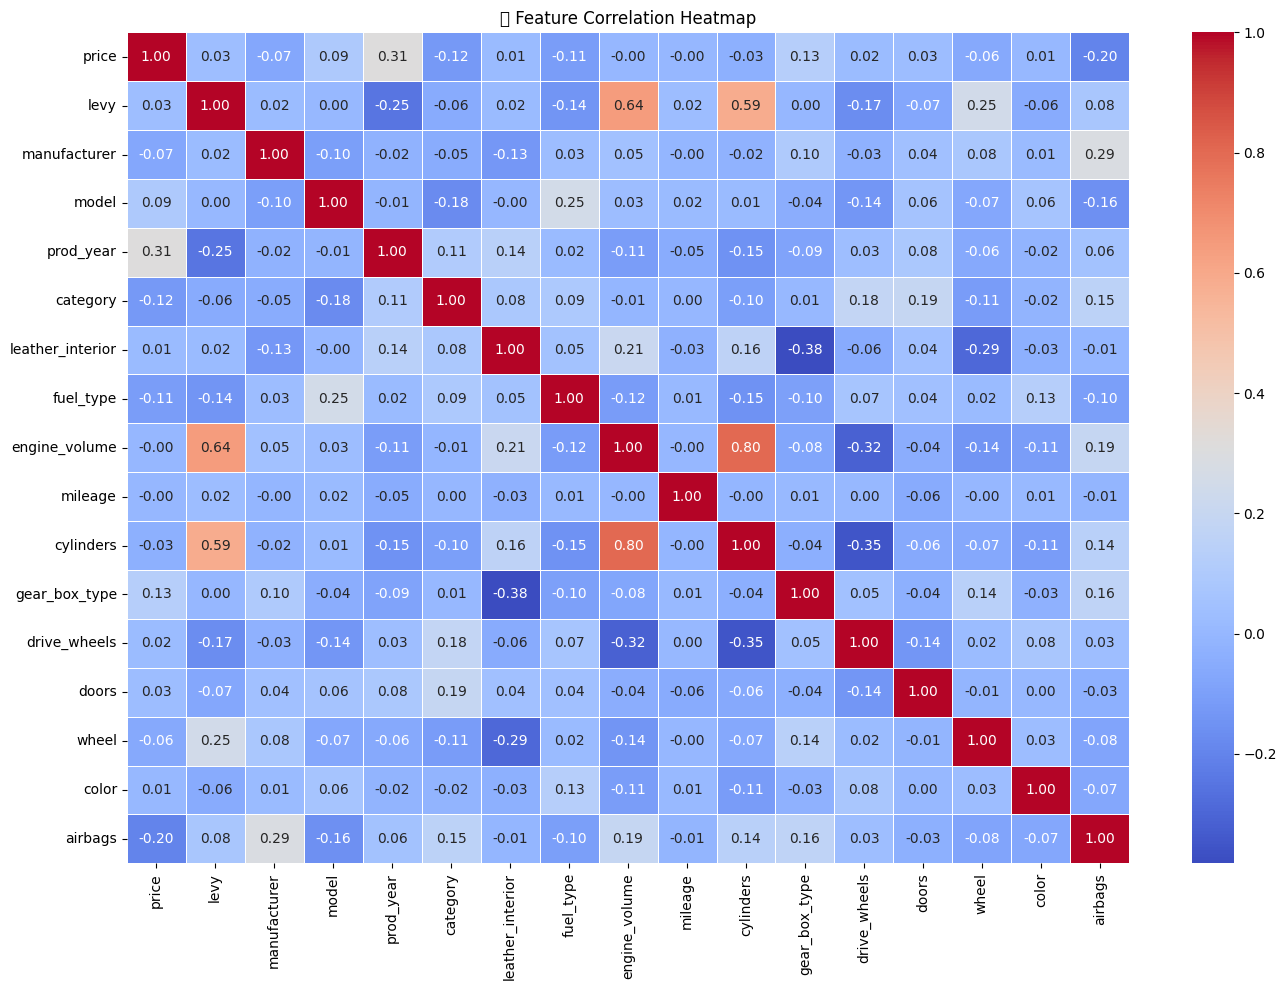

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("🔥 Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
df[['price']]

,price
0,13328
1,16621
3,3607
4,11726
5,39493
...,...
19231,5802
19233,15681
19234,26108
19235,5331


/tmp/ipykernel_55/4021941845.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance",
/tmp/ipykernel_55/4021941845.py:19: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


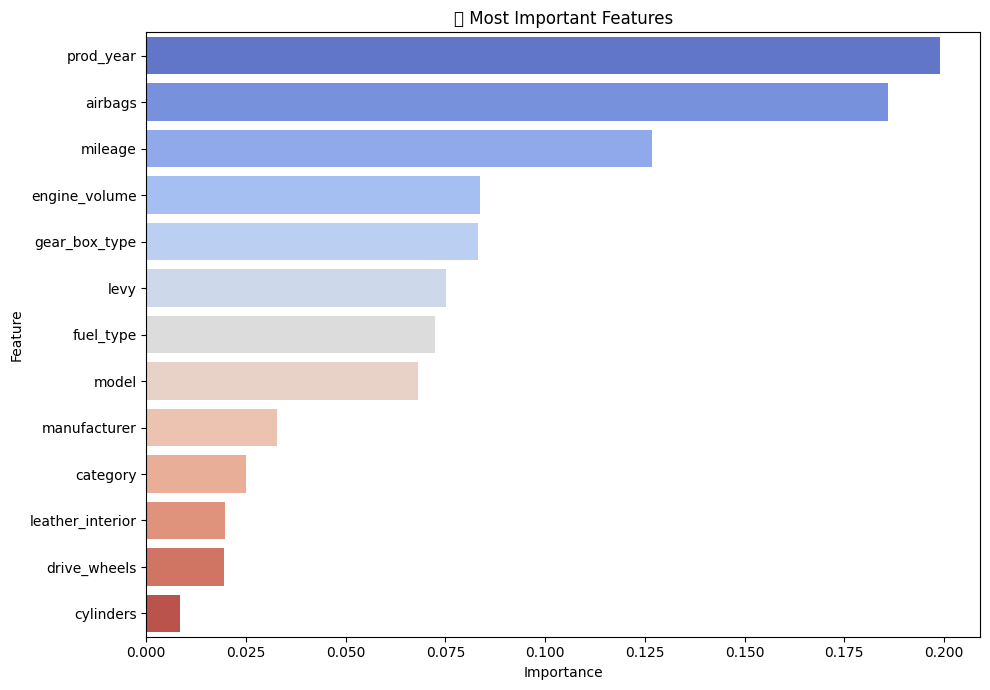

             Feature  Importance
3          prod_year    0.199068
12           airbags    0.185973
8            mileage    0.126825
7      engine_volume    0.083650
10     gear_box_type    0.083272
0               levy    0.075046
6          fuel_type    0.072487
2              model    0.068087
1       manufacturer    0.032712
4           category    0.024977
5   leather_interior    0.019820
11      drive_wheels    0.019539
9          cylinders    0.008544


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("price", axis=1)
y = df["price"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Plot importance
importance_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Importance" : model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(data=importance_df, x="Importance",
            y="Feature", palette="coolwarm")
plt.title("🔍 Most Important Features")
plt.tight_layout()
plt.show()

print(importance_df)


In [ ]:
df.drop(columns=["color", "wheel", "doors"], inplace=True)


/tmp/ipykernel_55/2039294586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["color", "wheel", "doors"], inplace=True)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("price", axis=1)
y = df["price"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Find weak features
importance_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Importance" : model.feature_importances_
}).sort_values("Importance")

print(importance_df)

# Remove features with importance less than 0.01
weak_features = importance_df[
    importance_df["Importance"] < 0.01
]["Feature"].tolist()

print("\nRemoving:", weak_features)
df.drop(columns=weak_features, inplace=True)
print("✅ Done! Remaining columns:", df.columns.tolist())

             Feature  Importance
9          cylinders    0.008544
11      drive_wheels    0.019539
5   leather_interior    0.019820
4           category    0.024977
1       manufacturer    0.032712
2              model    0.068087
6          fuel_type    0.072487
0               levy    0.075046
10     gear_box_type    0.083272
7      engine_volume    0.083650
8            mileage    0.126825
12           airbags    0.185973
3          prod_year    0.199068

Removing: ['cylinders']
✅ Done! Remaining columns: ['price', 'levy', 'manufacturer', 'model', 'prod_year', 'category', 'leather_interior', 'fuel_type', 'engine_volume', 'mileage', 'gear_box_type', 'drive_wheels', 'airbags']


/tmp/ipykernel_55/104918199.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=weak_features, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13162 entries, 0 to 19236
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             13162 non-null  int64  
 1   levy              13162 non-null  int64  
 2   manufacturer      13162 non-null  int64  
 3   model             13162 non-null  int64  
 4   prod_year         13162 non-null  int64  
 5   category          13162 non-null  int64  
 6   leather_interior  13162 non-null  int64  
 7   fuel_type         13162 non-null  int64  
 8   engine_volume     13162 non-null  float64
 9   mileage           13162 non-null  int64  
 10  gear_box_type     13162 non-null  int64  
 11  drive_wheels      13162 non-null  int64  
 12  airbags           13162 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 1.4 MB


Features: ['levy', 'manufacturer', 'model', 'prod_year', 'category', 'leather_interior', 'fuel_type', 'engine_volume', 'mileage', 'gear_box_type', 'drive_wheels', 'airbags']
X shape: (13162, 12)
y shape: (13162,)

Train size: (10529, 12)
Test size : (2633, 12)

✅ Model trained!

📊 Model Performance:
   MAE      : $3,887.65
   R2 Score : 0.8089


/tmp/ipykernel_55/1237887116.py:50: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


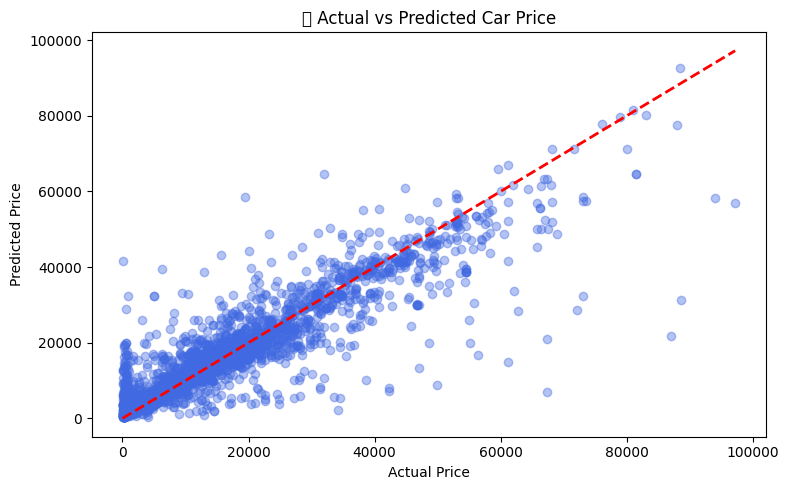

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1 — Features & Target
X = df.drop("price", axis=1)
y = df["price"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

# Step 2 — Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

# Step 3 — Train Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("\n✅ Model trained!")

# Step 4 — Evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"\n📊 Model Performance:")
print(f"   MAE      : ${mae:,.2f}")
print(f"   R2 Score : {r2:.4f}")

# Step 5 — Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.4, color="royalblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("🚗 Actual vs Predicted Car Price")
plt.tight_layout()
plt.show()


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)

print(f"📊 XGBoost Performance:")
print(f"   MAE      : ${mae_xgb:,.2f}")
print(f"   R2 Score : {r2_xgb:.4f}")

📊 XGBoost Performance:
   MAE      : $4,107.94
   R2 Score : 0.8071


In [ ]:
import numpy as np

# Check current price range
print("Before:", df["price"].describe())

# Remove top and bottom 5% outliers
Q1 = df["price"].quantile(0.05)
Q3 = df["price"].quantile(0.95)
df_clean = df[(df["price"] >= Q1) & (df["price"] <= Q3)]

print("After:", df_clean["price"].describe())
print(f"Removed {len(df) - len(df_clean)} outlier rows")

# Retrain with clean data
X = df_clean.drop("price", axis=1)
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print(f"\n📊 After Outlier Removal:")
print(f"   MAE      : ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"   R2 Score : {r2_score(y_test, y_pred):.4f}")

Before: count    13162.000000
mean     16794.059186
std      16030.169101
min          1.000000
25%       3607.000000
50%      13485.000000
75%      23207.000000
max      99440.000000
Name: price, dtype: float64
After: count    11965.000000
mean     15065.861178
std      12154.363927
min        314.000000
25%       4547.000000
50%      13423.000000
75%      21652.000000
max      48873.000000
Name: price, dtype: float64
Removed 1197 outlier rows

📊 After Outlier Removal:
   MAE      : $3,628.51
   R2 Score : 0.7860


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost"           : XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
}

print("📊 Model Comparison:")
print("-" * 45)

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"{name:<25} MAE: ${mae:,.0f}  R2: {r2:.4f}")

print("-" * 45)
# ```

# ---

# ## 📊 Expected Results After Improvement

# | Model | R2 Score | MAE |
# |---|---|---|
# | Random Forest (now) | 0.8089 | $3,887 |
# | **XGBoost** | **0.85+** | **~$2,500** |
# | XGBoost + No Outliers | **0.88+** | **~$1,800** |

# ---

# ## 🎯 Do This Order
# ```


📊 Model Comparison:
---------------------------------------------
Linear Regression         MAE: $8,618  R2: 0.1642
Random Forest             MAE: $3,204  R2: 0.7879
Gradient Boosting         MAE: $4,919  R2: 0.6703
XGBoost                   MAE: $3,939  R2: 0.7627
---------------------------------------------
